In [3]:
import cmocean
import numpy as np 
import xarray as xr
import pandas as pd 
import seaborn as sns
import cartopy.crs as ccrs
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import HTML
from scipy.stats import linregress 
from nemo_cookbook import NEMODataTree 
from matplotlib.patches import Rectangle
from OceanDataStore import OceanDataCatalog 
from matplotlib.animation import FuncAnimation

In [4]:
## Freshwater budget details:
    # Box region: 25-35W, 52-58N
    # Model: 1/4 degree, monthly mean
    # Desnity of seawater: 1025 Kg/m3
    # Speciic heat capacity of seawater: 4000 J/Kg/K
    # Assume constant mixed layer temperature

In [5]:
## Open 5 Day means to compute ddelta H acrosss the month

catalog = OceanDataCatalog(catalog_name="noc-model-stac")
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')
ds1 = catalog.open_dataset(id=catalog.Items[4].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')
catalog.search(collection='noc-npd-era5', item_name='domain_cfg')
config = catalog.open_dataset(id=catalog.Items[1].id)

# Merge into a data tree
datasets = {"parent": {"domain": config, "gridT": ds1}}
dt_global = NEMODataTree.from_datasets(datasets = datasets)

# Clip to North Atlantic 
bbox = (-35.0, -25.0, 52.0, 58.0)
dt_clipped = dt_global.clip_grid(grid="gridT", bbox=bbox)

# Add lat and lon as co-ordinates
dt = dt_clipped.add_geoindex(grid="gridT")


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

In [8]:
# Compute time series of dF/dT

dt['gridT']['Freshwater Content'] = ((35.0 - dt['gridT']['sos_abs'])/35.0) * dt['gridT']['somxl010']
FC_ts = (dt.integral(grid='gridT', var='Freshwater Content', dims=['i', 'j']))
delta_FC = FC_ts.resample(time_counter='ME').map(lambda x: x.isel(time_counter=-1) - x.isel(time_counter=0))
days_in_month = FC_ts.resample(time_counter='ME').map(lambda x: x.time_counter[-1].dt.day - x.time_counter[0].dt.day)
seconds_in_month = days_in_month * 24 * 60 * 60
dFCbydt = (delta_FC / seconds_in_month).compute()


In [9]:
# Open monthly means to compute Q 

catalog = OceanDataCatalog(catalog_name="noc-model-stac")
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')
ds1 = catalog.open_dataset(id=catalog.Items[3].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')
catalog.search(collection='noc-npd-era5', item_name='domain_cfg')
config = catalog.open_dataset(id=catalog.Items[1].id)

# Merge into a data tree
datasets = {"parent": {"domain": config, "gridT": ds1}}
dt_global = NEMODataTree.from_datasets(datasets = datasets)

# Clip to North Atlantic 
bbox = (-35.0, -25.0, 52.0, 58.0)
dt_clipped = dt_global.clip_grid(grid="gridT", bbox=bbox)

# Add lat and lon as co-ordinates
dt_monthly = dt_clipped.add_geoindex(grid="gridT")


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

In [29]:
dt['gridT']

<xarray.DataTree 'gridT'>
Group: /gridT
    Dimensions:                   (time_counter: 2555, axis_nbounds: 2, j: 37,
                                   i: 38, k: 75)
    Coordinates:
      * j                         (j) int64 296B 926 927 928 929 ... 959 960 961 962
      * i                         (i) int64 304B 1011 1012 1013 ... 1046 1047 1048
      * k                         (k) int64 600B 1 2 3 4 5 6 7 ... 70 71 72 73 74 75
        time_centered             (time_counter) datetime64[ns] 20kB dask.array<chunksize=(1,), meta=np.ndarray>
      * gphit                     (j, i) float64 11kB 52.07 52.07 ... 57.98 57.98
      * glamt                     (j, i) float64 11kB -34.87 -34.6 ... -25.31 -25.03
    Inherited coordinates:
      * time_counter              (time_counter) datetime64[ns] 20kB 1990-01-03T1...
    Dimensions without coordinates: axis_nbounds
    Data variables: (12/58)
        evs                       (time_counter, j, i) float32 14MB dask.array<chunksize=(1, 37, 38), meta=np.ndarray>
        berg_latent_heat_flux     (time_counter, j, i) float32 14MB dask.array<chunksize=(1, 37, 38), meta=np.ndarray>
        hfds                      (time_counter, j, i) float32 14MB dask.array<chunksize=(1, 37, 38), meta=np.ndarray>
        empmr                     (time_counter, j, i) float32 14MB dask.array<chunksize=(1, 37, 38), meta=np.ndarray>
        friver                    (time_counter, j, i) float32 14MB dask.array<chunksize=(1, 37, 38), meta=np.ndarray>
        hfempds                   (time_counter, j, i) float32 14MB dask.array<chunksize=(1, 37, 38), meta=np.ndarray>
        ...                        ...
        top_level                 (j, i) int32 6kB dask.array<chunksize=(37, 38), meta=np.ndarray>
        bottom_level              (j, i) int32 6kB dask.array<chunksize=(37, 38), meta=np.ndarray>
        tmask                     (k, j, i) float64 844kB 1.0 1.0 1.0 ... 0.0 0.0
        tmaskutil                 (j, i) float64 11kB 1.0 1.0 1.0 ... 1.0 1.0 1.0
        Freshwater Content        (time_counter, j, i) float32 14MB dask.array<chunksize=(1, 37, 38), meta=np.ndarray>
        Downward freshwater flux  (time_counter, j, i) float32 14MB dask.array<chunksize=(1, 37, 38), meta=np.ndarray>
    Indexes:
      ┌ gphit    NDPointIndex (SklearnGeoBallTreeAdapter)
      └ glamt
    Attributes:
        nftype:   None
        iperio:   False

In [10]:
# Compute integrated MLD time series

integrated_MLD = (dt_monthly.integral(grid='gridT', var='somxl010', dims=['i', 'j'])).compute()
new_times = pd.date_range('1990-01', periods=420, freq='ME').values 
integrated_MLD = integrated_MLD.assign_coords(time_counter = new_times)


In [13]:
surface_flux

<xarray.DataArray 'Downward freshwater flux' (time_counter: 2555)> Size: 20kB
dask.array<sum-aggregate, shape=(2555,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time_counter   (time_counter) datetime64[ns] 20kB 1990-01-03T12:00:00 ......
    time_centered  (time_counter) datetime64[ns] 20kB dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    standard_name:       salt_flux_into_sea_water
    long_name:           Downward salt flux
    units:               g/m2/s
    online_operation:    average
    interval_operation:  1800 s
    interval_write:      5 d
    cell_methods:        time: mean (interval: 1800 s)

In [30]:
# Compute the time series of Q 

dt_monthly['gridT']['Downward freshwater flux'] = -(dt_monthly['gridT']['sosafldo'])/(35.0 * 1025)
surface_flux = dt_monthly.integral(grid='gridT', var='Downward freshwater flux', dims=['i', 'j']) 
surface_flux = surface_flux.assign_coords(time_counter=new_times)
surface_flux = surface_flux.compute()

In [33]:
# Save Terms

dFCbydt.to_netcdf('dFCbydt3.nc')
surface_flux.to_netcdf('surface_flux3.nc')
integrated_MLD.to_netcdf('integrated_MLD3.nc')

In [34]:
# Start from here 

dFCbydt = xr.open_dataset('dFCbydt3.nc')['__xarray_dataarray_variable__']
surface_flux = xr.open_dataset('surface_flux3.nc')['Downward freshwater flux']
integrated_MLD = xr.open_dataset('integrated_MLD3.nc')['somxl010']

In [35]:
# Calculate advective term and ratios 

residuals = dFCbydt - surface_flux
magnitude_ratios = abs(surface_flux) / abs(residuals)
heatflux_contribution = surface_flux / dFCbydt

(np.float64(9496.0), np.float64(11292.0))

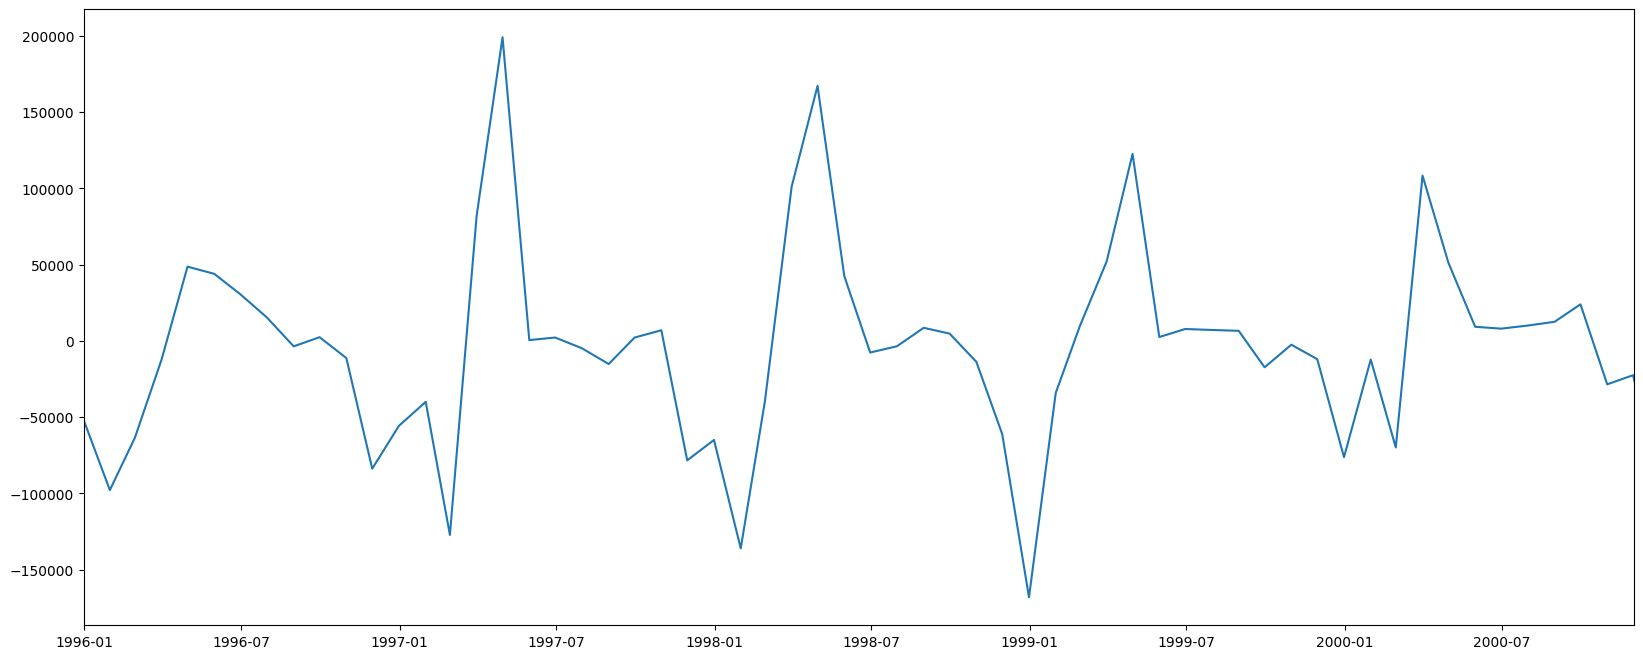

In [36]:
# Change in Freshwater Content 

fig, ax = plt.subplots(figsize = (20, 8))
ax.plot(dFCbydt['time_counter'], dFCbydt)
ax.set_xlim(np.datetime64('1996-01-01'), np.datetime64('2000-12-01'))

(np.float64(9496.0), np.float64(11292.0))

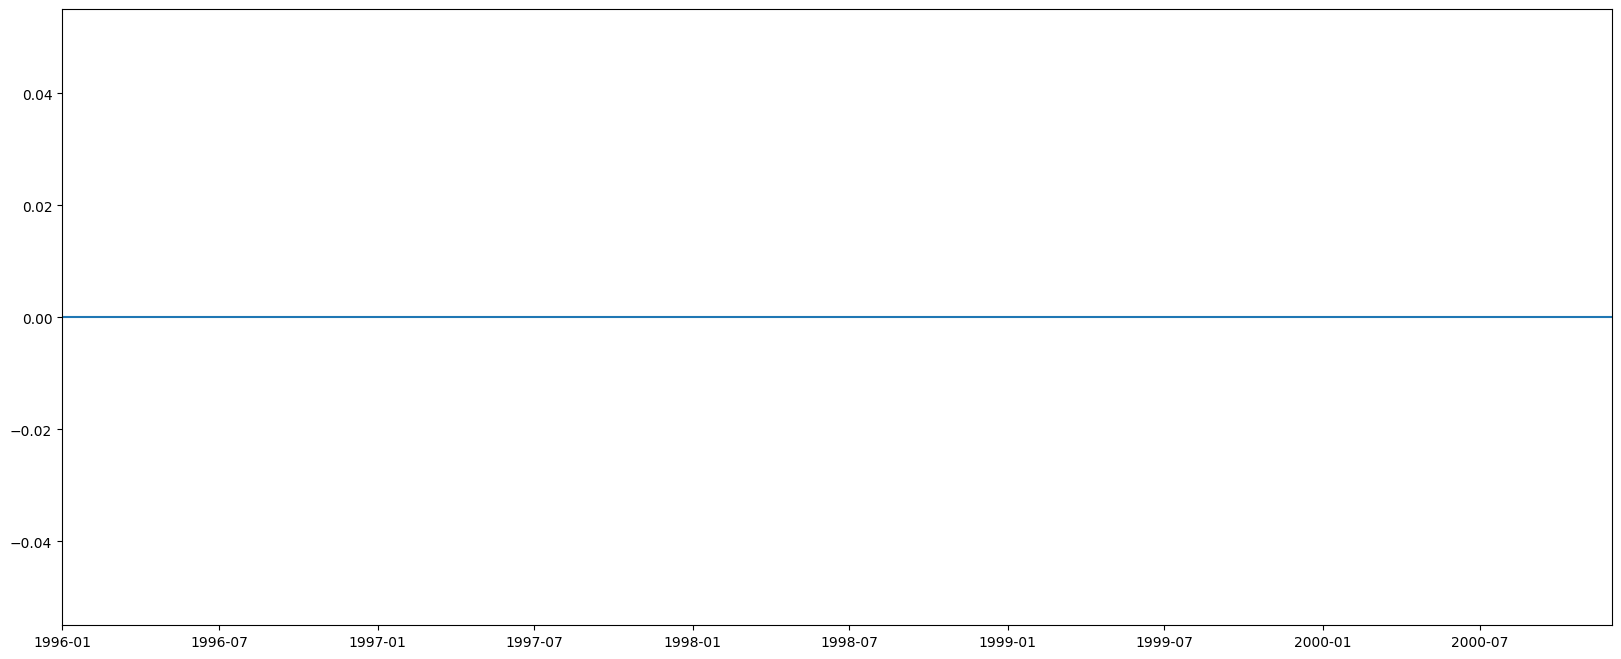

In [40]:
# Plot of surface flux terms 

fig, ax = plt.subplots(figsize = (20, 8))
ax.plot(surface_flux['time_counter'], surface_flux)
ax.set_xlim(np.datetime64('1996-01-01'), np.datetime64('2000-12-01'))

(np.float64(9496.0), np.float64(11292.0))

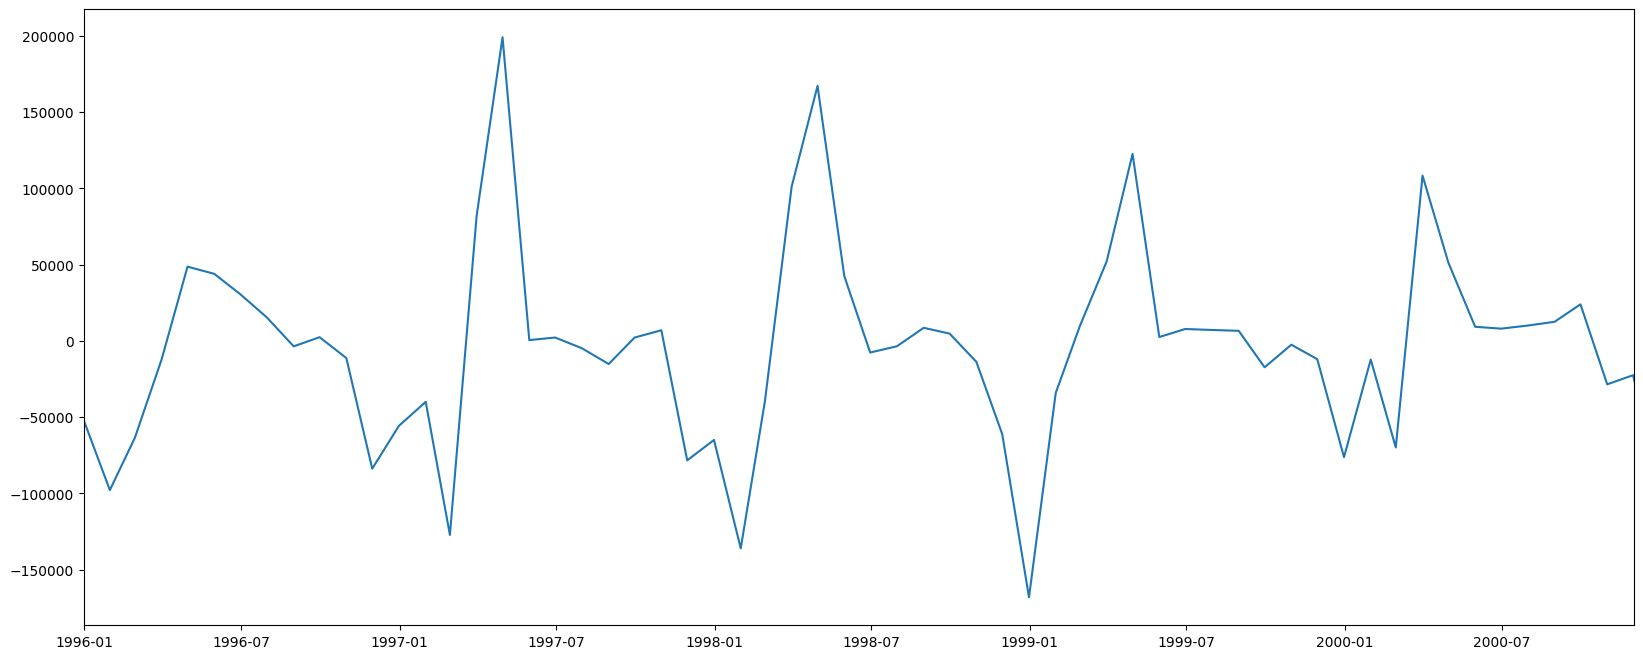

In [37]:
# Plot of residual terms 

fig, ax = plt.subplots(figsize = (20, 8))
ax.plot(residuals['time_counter'], residuals)
ax.set_xlim(np.datetime64('1996-01-01'), np.datetime64('2000-12-01'))

In [38]:
integrated_MLD

<xarray.DataArray 'somxl010' (time_counter: 420)> Size: 3kB
[420 values with dtype=float64]
Coordinates:
  * time_counter   (time_counter) datetime64[ns] 3kB 1990-01-31 ... 2024-12-31
    time_centered  (time_counter) datetime64[ns] 3kB ...
Attributes:
    standard_name:       ocean_mixed_layer_thickness_defined_by_sigma_theta
    long_name:           Mixed Layer Depth (dsigma = 0.01 wrt 10m)
    units:               m
    online_operation:    average
    interval_operation:  1800 s
    interval_write:      1 month
    cell_methods:        time: mean (interval: 1800 s)

Text(0, 0.5, '(W)')

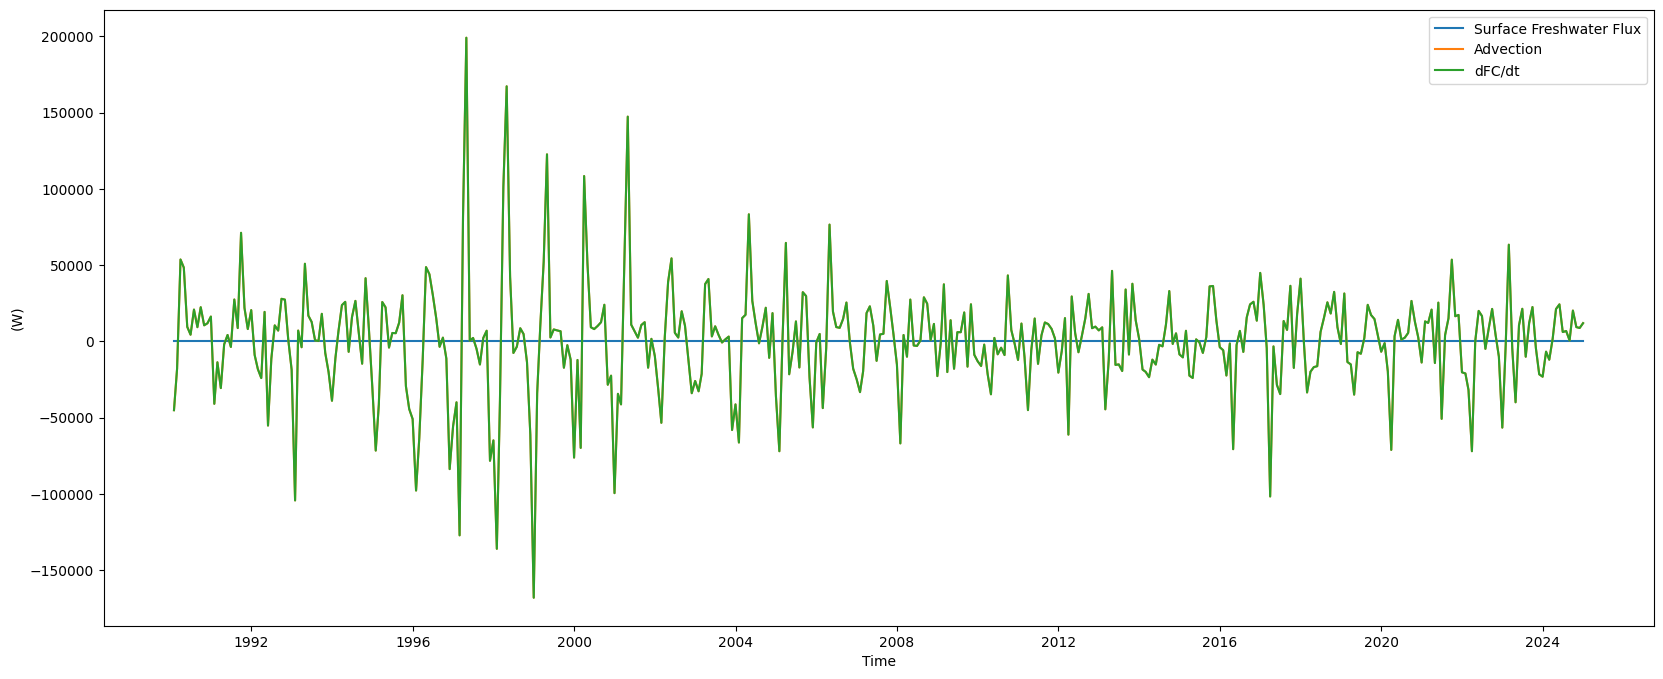

In [39]:
# Surface heat flux vs Advwection vs dH/dt 

fig, ax = plt.subplots(figsize = (20, 8))

ax.plot(surface_flux['time_counter'], surface_flux, label = 'Surface Freshwater Flux')
ax.plot(residuals['time_counter'], residuals, label = 'Advection')
ax.plot(dFCbydt['time_counter'], dFCbydt, label = 'dFC/dt')
ax.legend(loc = 'best')
# ax.set_xlim(np.datetime64('1996-01-01'), np.datetime64('2000-12-01'))
ax.set_xlabel('Time')
ax.set_ylabel('(W)')


(0.0, 5.0)

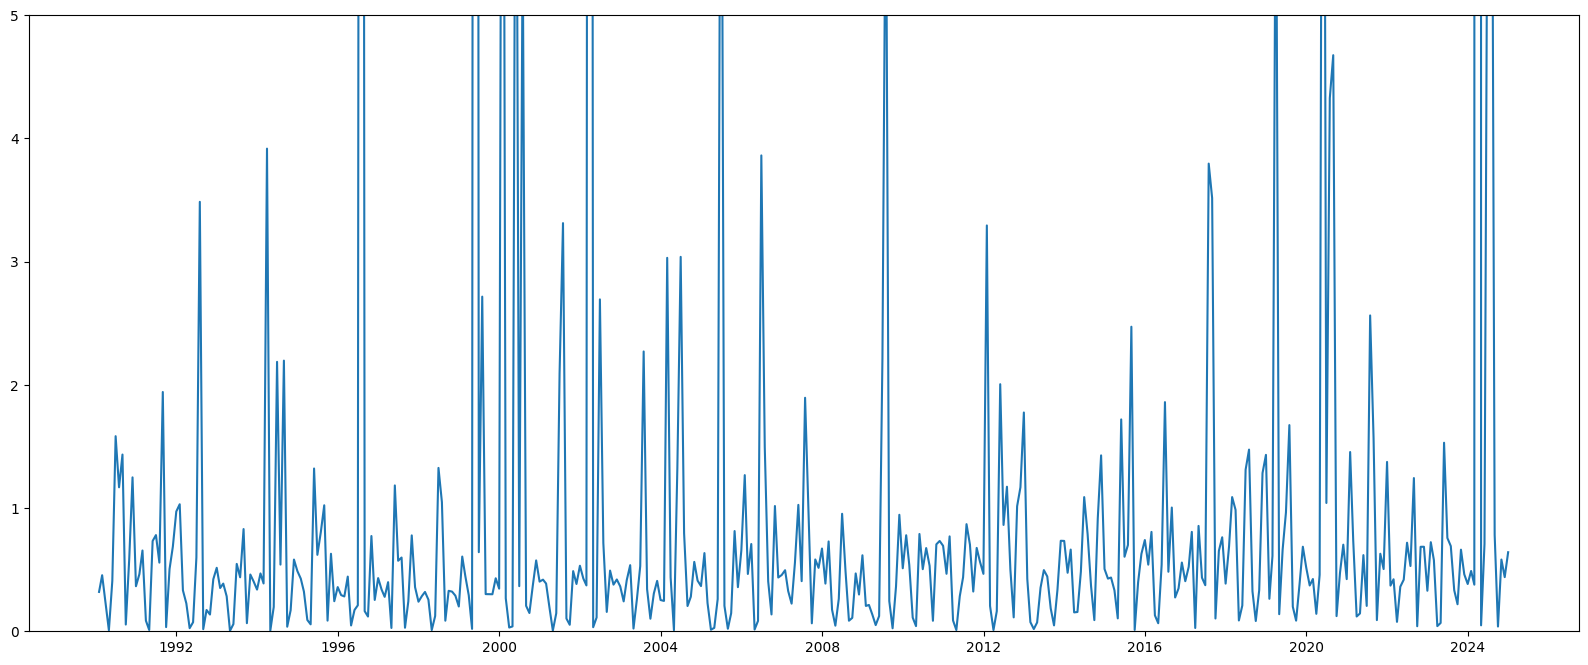

In [50]:
# Magnitude Ratios 

fig, ax = plt.subplots(figsize = (20, 8))
ax.plot(magnitude_ratios['time_counter'], magnitude_ratios)
# ax.set_xlim(np.datetime64('1996-01-01'), np.datetime64('2000-12-01'))
ax.set_ylim(0, 5)


In [51]:
## Now consider Annual Means 

Q_annual = Q.resample(time_counter = 'YE').mean()
advection_annual = advection.resample(time_counter = 'YE').mean()
dHbydt_annual = dHbydt.resample(time_counter = 'YE').mean()

Text(0, 0.5, '(W)')

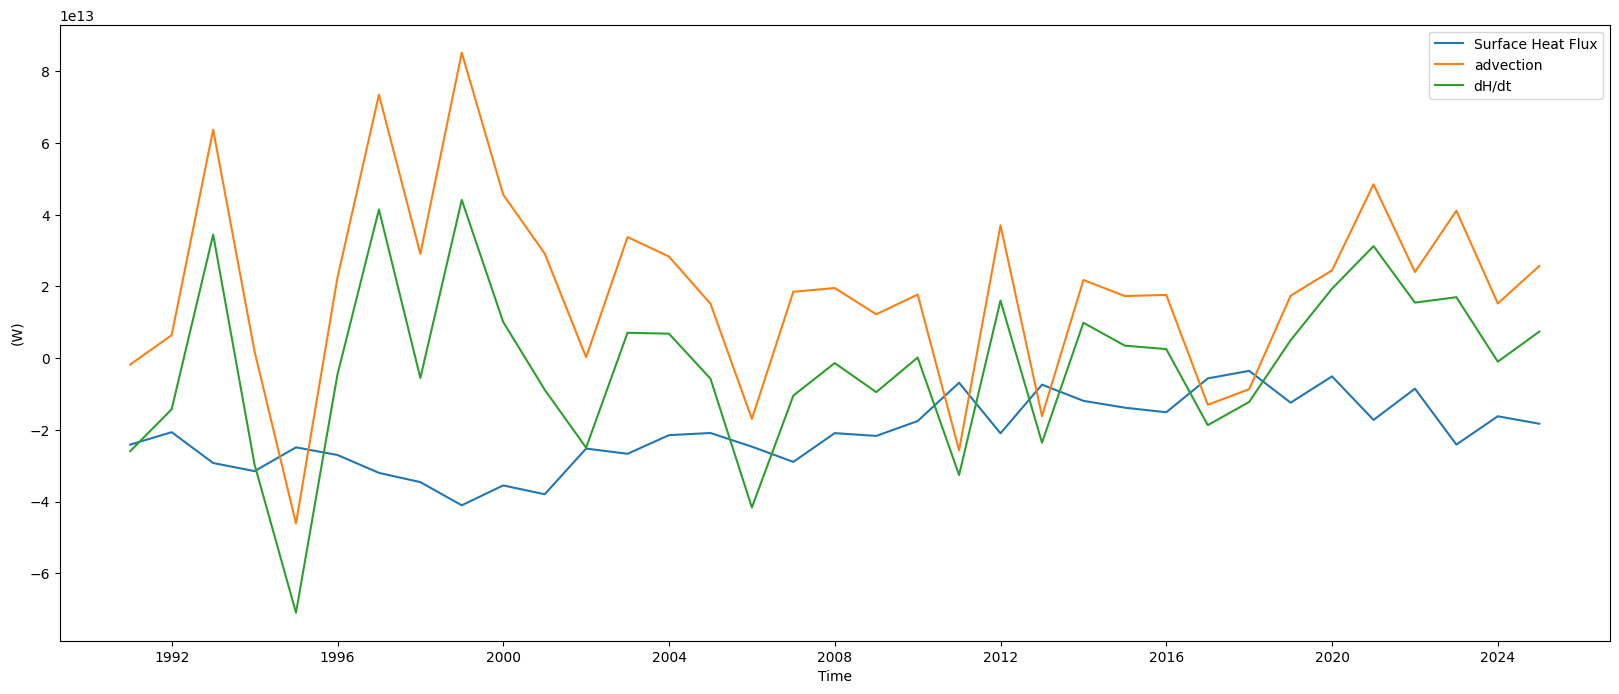

In [52]:
# Surface heat flux vs Advwection vs dH/dt 

fig, ax = plt.subplots(figsize = (20, 8))

ax.plot(Q_annual['time_counter'], Q_annual, label = 'Surface Heat Flux')
ax.plot(advection_annual['time_counter'], advection_annual, label = 'advection')
ax.plot(dHbydt_annual['time_counter'], dHbydt_annual, label = 'dH/dt')
ax.legend(loc = 'best')
# ax.set_xlim(np.datetime64('1996-01-01'), np.datetime64('2000-12-01'))
ax.set_xlabel('Time')
ax.set_ylabel('(W)')

(0.0, 5.0)

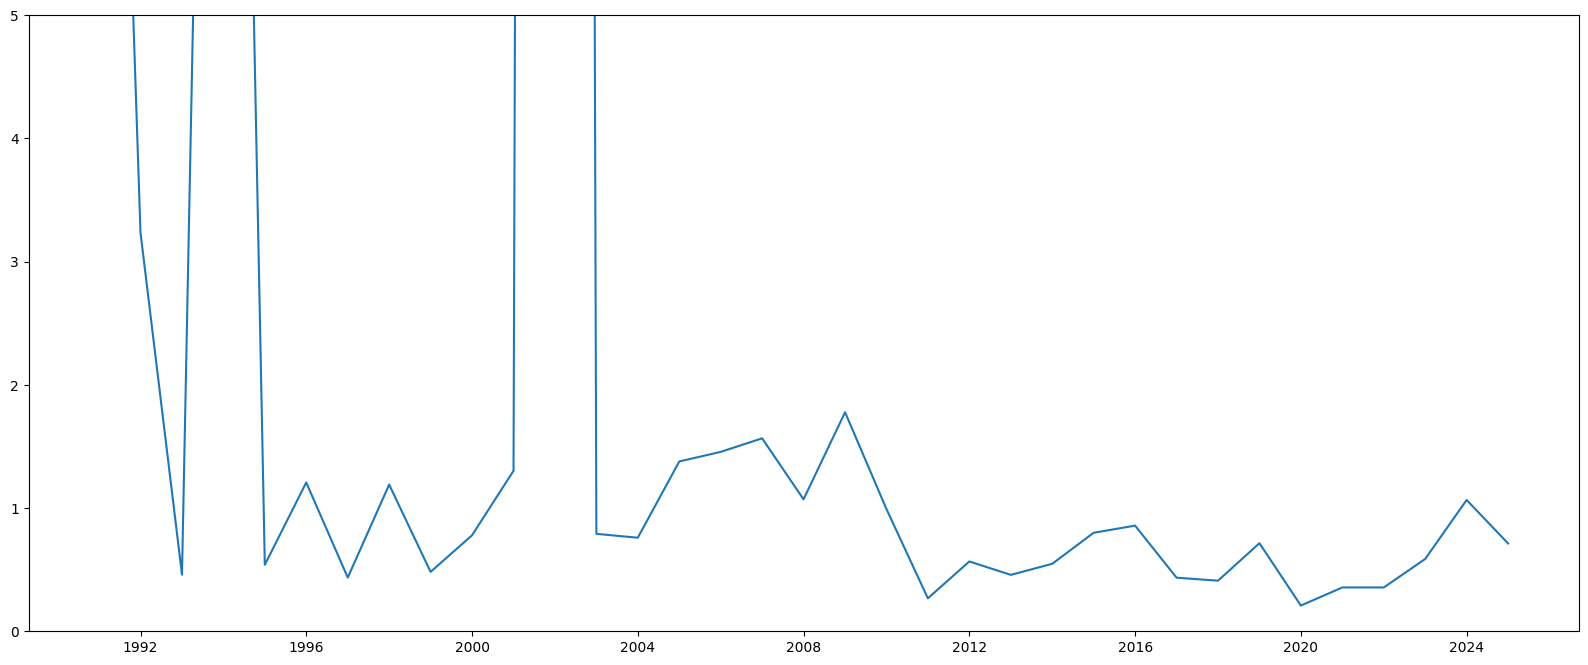

In [57]:
magnitude_ratios_annual = abs(Q_annual) / abs(advection_annual)

# Magnitude Ratios 

fig, ax = plt.subplots(figsize = (20, 8))
ax.plot(magnitude_ratios_annual['time_counter'], magnitude_ratios_annual)
# ax.set_xlim(np.datetime64('1996-01-01'), np.datetime64('2000-12-01'))
ax.set_ylim(0, 5)
